In [104]:
!pip install yfinance
!pip install bs4
!pip install nbformat
!pip install matplotlib

In [105]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup

In [102]:
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [103]:
tesla = yf.Ticker("TSLA")

In [106]:
tesla_data=tesla.history(period="max")

In [107]:
tesla_data.reset_index(inplace=True)
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [108]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
response=requests.get(url)
html_data=response.text

In [109]:
soup=BeautifulSoup(html_data,"html.parser")

In [110]:
# 1. Create an Empty DataFrame
tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

# 2. Find the Relevant Table
tables = soup.find_all("table")

# 3. Check for the Tesla Quarterly Revenue Table
for table in tables:
    if "Tesla Quarterly Revenue" in table.text:
        tesla_table = table
        break

# 4. Iterate Through Rows in the Table Body
for row in tesla_table.find("tbody").find_all("tr"):
    
    # 5. Extract Data from Columns
    col = row.find_all("td")
    
    if len(col) >= 2:
        date = col[0].text.strip()
        revenue = col[1].text.strip()
        
        # 6. Append Data to the DataFrame
        tesla_revenue = pd.concat([
            tesla_revenue,
            pd.DataFrame({
                "Date": [date],
                "Revenue": [revenue]
            })
        ], ignore_index=True)

tesla_revenue.head()

,Date,Revenue
0,2022-09-30,"$21,454"
1,2022-06-30,"$16,934"
2,2022-03-31,"$18,756"
3,2021-12-31,"$17,719"
4,2021-09-30,"$13,757"


In [121]:
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\$',"",regex=True)

In [122]:
tesla_revenue.dropna(inplace=True)

tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

In [111]:
tesla_revenue.tail()

,Date,Revenue
49,2010-06-30,$28
50,2010-03-31,$21
51,2009-12-31,
52,2009-09-30,$46
53,2009-06-30,$27


**QUESTION 2**

In [114]:
gme=yf.Ticker("GME")

In [115]:
gme_data=gme.history(period="max")

In [116]:
gme_data.reset_index(inplace=True)
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691666,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683251,1.687459,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [112]:
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
response=requests.get(url)
html_data_2=response.text

In [113]:
soup=BeautifulSoup(html_data_2,"html.parser")

In [117]:
import pandas as pd

# 1. Create an empty DataFrame
gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])

# 2. Find the GameStop Revenue table
tables = soup.find_all("table")

# 3. Check for the GameStop Revenue table
for table in tables:
    if "GameStop Quarterly Revenue" in table.text:
        gme_table = table
        break

# 4. Iterate through the rows
for row in gme_table.find("tbody").find_all("tr"):
    
    # 5. Extract the columns
    col = row.find_all("td")
    
    if len(col) >= 2:
        date = col[0].text.strip()
        revenue = col[1].text.strip()
        
        # Remove dollar sign and comma
        revenue = revenue.replace("$", "").replace(",", "")
        
        # 6. Append the data
        gme_revenue = pd.concat([
            gme_revenue,
            pd.DataFrame({
                "Date": [date],
                "Revenue": [revenue]
            })
        ], ignore_index=True)

# Display first 5 rows
gme_revenue.tail()

,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


In [118]:
import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

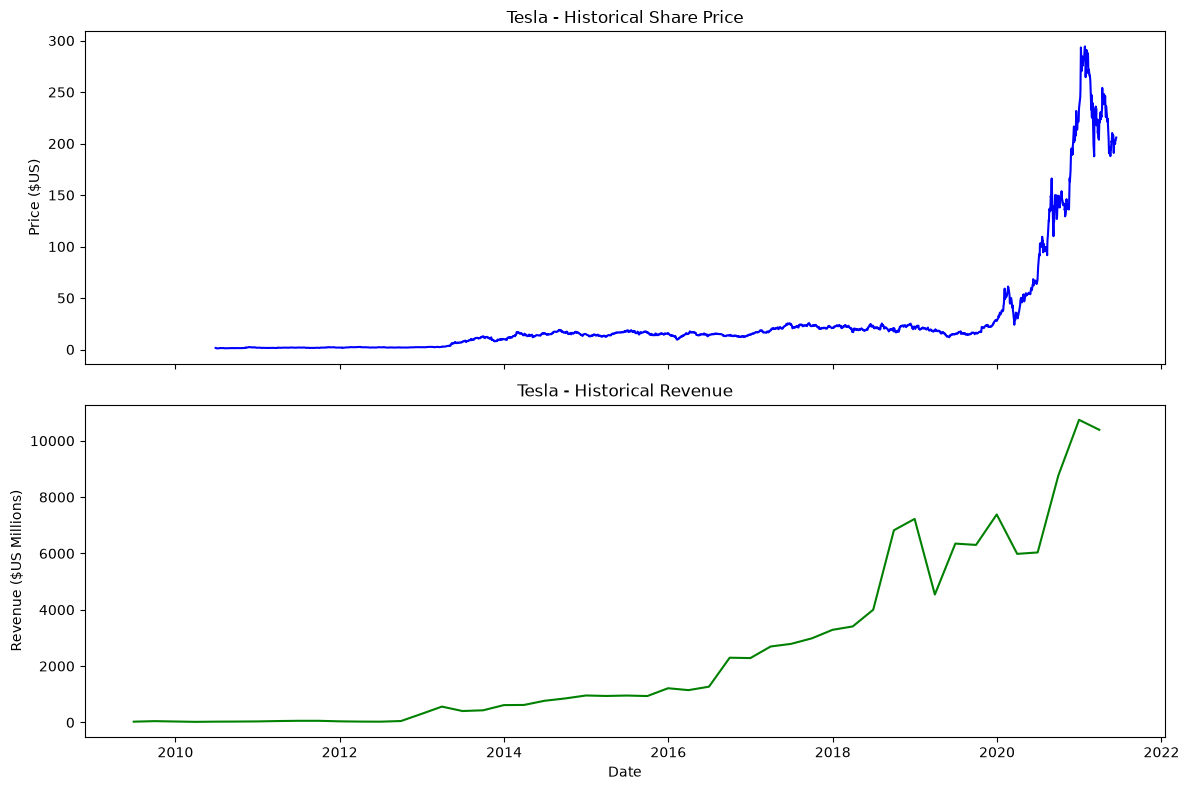

In [123]:
make_graph(tesla_data, tesla_revenue, 'Tesla')

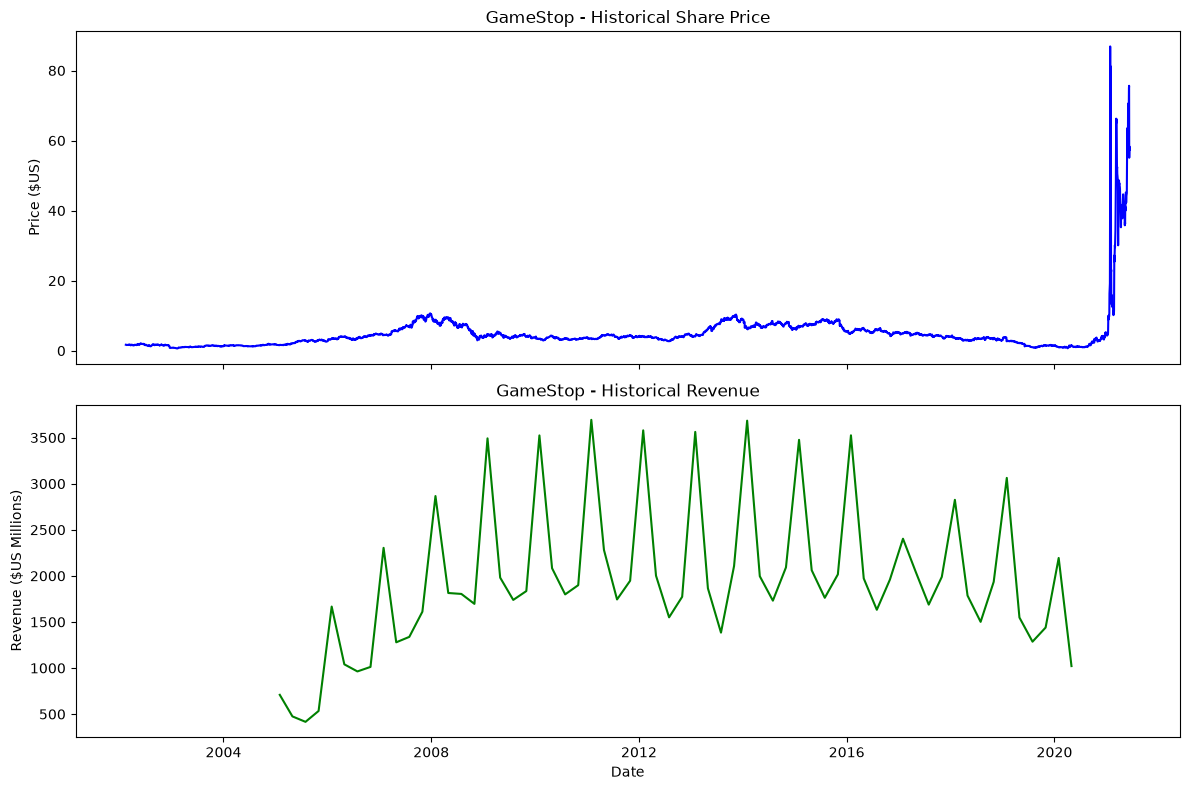

In [120]:
make_graph(gme_data, gme_revenue, 'GameStop')